# JOBSHEET 2 (Klasifikasi Gambar)

## Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

try dataset MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


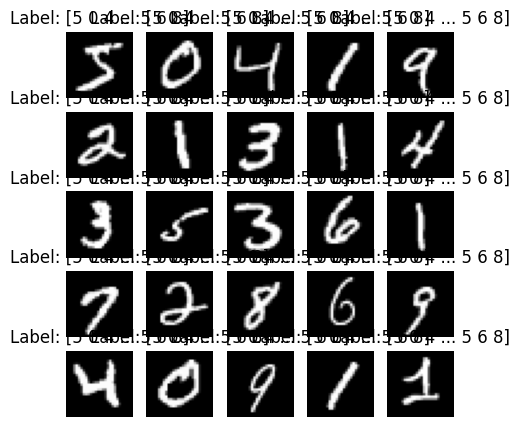

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train}")
  plt.axis('off')
plt.show()

## Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Traditional

using SVM algorithm

In [2]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# svm
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena svm berat
y_pred = clf.predict(x_test_flat)

print("Akurasi", accuracy_score(y_test, y_pred))

Akurasi 0.9101


## Praktikum D3 - Membangung CNN Sederhana

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9470 - loss: 0.1783 - val_accuracy: 0.9787 - val_loss: 0.0725
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9807 - loss: 0.0624 - val_accuracy: 0.9813 - val_loss: 0.0644
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9868 - loss: 0.0415 - val_accuracy: 0.9802 - val_loss: 0.0677
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9906 - loss: 0.0288 - val_accuracy: 0.9888 - val_loss: 0.0485
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9935 - loss: 0.0207 - val_accuracy: 0.9870 - val_loss: 0.0472


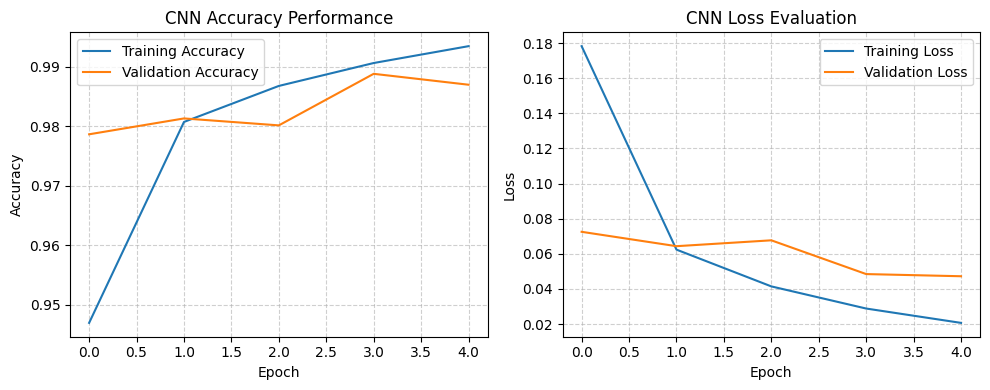

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Tugas kecil: Tambahkan satu lapisan Conv2D lagi sebelum Flatten. Apakah akurasinya meningkat?

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9501 - loss: 0.1599 - val_accuracy: 0.9817 - val_loss: 0.0636
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9832 - loss: 0.0534 - val_accuracy: 0.9873 - val_loss: 0.0422
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 87s 31ms/step - accuracy: 0.9888 - loss: 0.0359 - val_accuracy: 0.9885 - val_loss: 0.0380
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 26ms/step - accuracy: 0.9916 - loss: 0.0265 - val_accuracy: 0.9882 - val_loss: 0.0407
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 86s 28ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9905 - val_loss: 0.0327


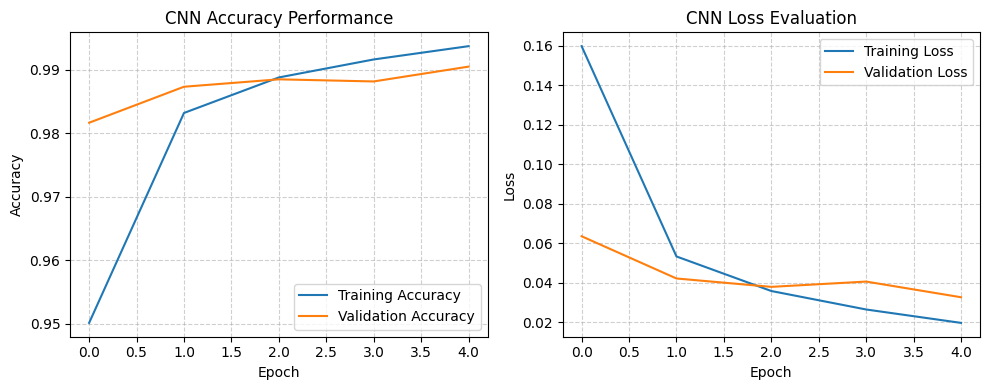

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # add conv2d
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Ya, penambahan lapisan Conv2D terbukti meningkatkan akurasi validasi (dari stagnasi ~0.988 menjadi ~0.991) karena arsitektur jaringan yang lebih dalam memungkinkan ekstraksi pola fitur visual yang lebih kompleks. Meskipun demikian, penambahan kompleksitas ini memicu indikasi awal *overfitting*, yang dibuktikan oleh tren kenaikan *validation loss* setelah epoch kedua sementara *training loss* terus mengalami penurunan.

## Praktikum D4 - Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 38ms/step - accuracy: 0.1995 - loss: 2.3962 - val_accuracy: 0.3074 - val_loss: 1.7890
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.4239 - loss: 1.5514 - val_accuracy: 0.4964 - val_loss: 1.3709
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.5308 - loss: 1.3031 - val_accuracy: 0.5540 - val_loss: 1.2530
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.5897 - loss: 1.1599 - val_accuracy: 0.5912 - val_loss: 1.1614
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.6291 - loss: 1.0627 - val_accuracy: 0.5976 - val_loss: 1.1807
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.6561 - loss: 0.9875 - val_accuracy: 0.6132 - val_loss: 1.1312
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.6759 - loss: 0.9277 - val_accuracy: 0.6352 - val_loss: 1.0970
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.7000 -

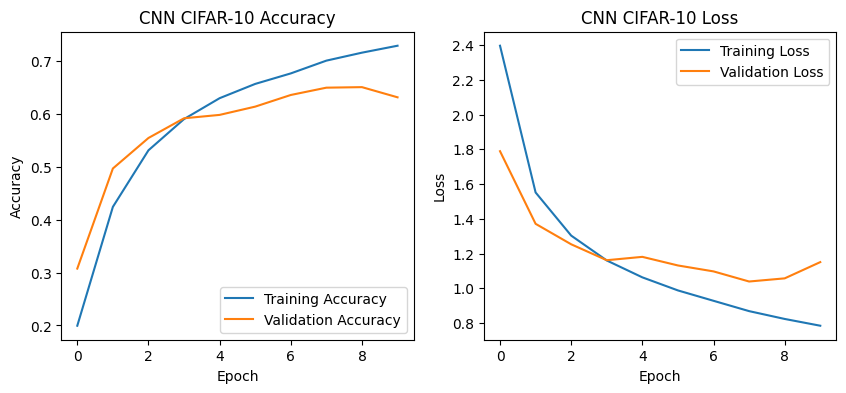

In [7]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

# plothistory
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

tugas kecil: tambahkan Dropout(0.5) sebelum lapisan Dense terakhir. Apa pengaruhnya pada overfitting?

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.2436 - loss: 1.9741 - val_accuracy: 0.4008 - val_loss: 1.6979
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.3160 - loss: 1.7629 - val_accuracy: 0.5058 - val_loss: 1.4376
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 39ms/step - accuracy: 0.3503 - loss: 1.6893 - val_accuracy: 0.5400 - val_loss: 1.3719
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.3806 - loss: 1.6233 - val_accuracy: 0.5372 - val_loss: 1.3330
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.4029 - loss: 1.5735 - val_accuracy: 0.5824 - val_loss: 1.2605
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.4215 - loss: 1.5312 - val_accuracy: 0.5758 - val_loss: 1.2285
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4385 - loss: 1.4922 - val_accuracy: 0.5978 - val_loss: 1.1808
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.4454 -

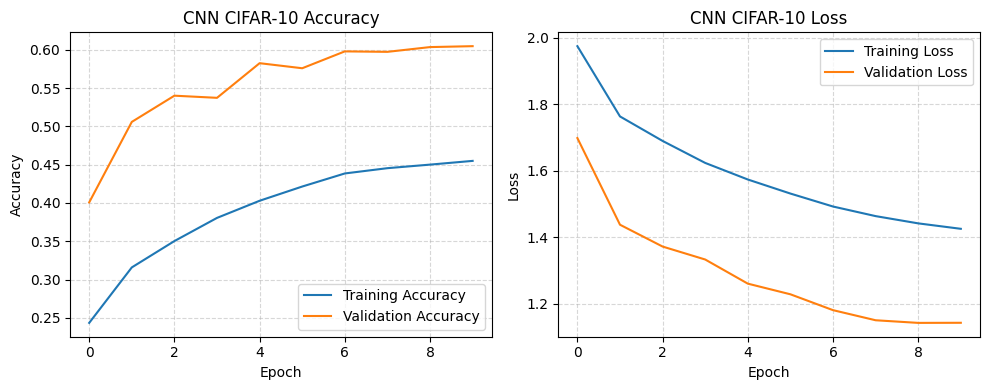

In [12]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, layers, models
from tensorflow.keras.datasets import cifar10

# load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# normalisasi matrik pixel ke skala [0,1]
x_train_cnn = x_train.astype('float32') / 255.0
x_test_cnn = x_test.astype('float32') / 255.0

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), #injeksi dropout sebelum layer klasifikasi akhir
    layers.Dense(10, activation='softmax')
])

# kompilasi model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# pelatihan model
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1
)

plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## Praktikum D5 - Transfer Learning dengan Model Pra-Latih

Bagaimana jika kita gunakan “otak” yang sudah cerdas? Misalnya VGG16 atau ResNet50
yang sudah dilatih di ImageNet. Kita tinggal memanfaatkannya.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 570s 404ms/step - accuracy: 0.4509 - loss: 2.3307 - val_accuracy: 0.5316 - val_loss: 1.3517
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 530s 376ms/step - accuracy: 0.5742 - loss: 1.2281 - val_accuracy: 0.5722 - val_loss: 1.2452
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 566s 402ms/step - accuracy: 0.6068 - loss: 1.1348 - val_accuracy: 0.5948 - val_loss: 1.2113
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 585s 416ms/step - accuracy: 0.6281 - loss: 1.0781 - val_accuracy: 0.5930 - val_loss: 1.1973
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 566s 403ms/step - accuracy: 0.6410 - loss: 1.0408 - val_accuracy: 0.5892 - val_loss: 1.2320


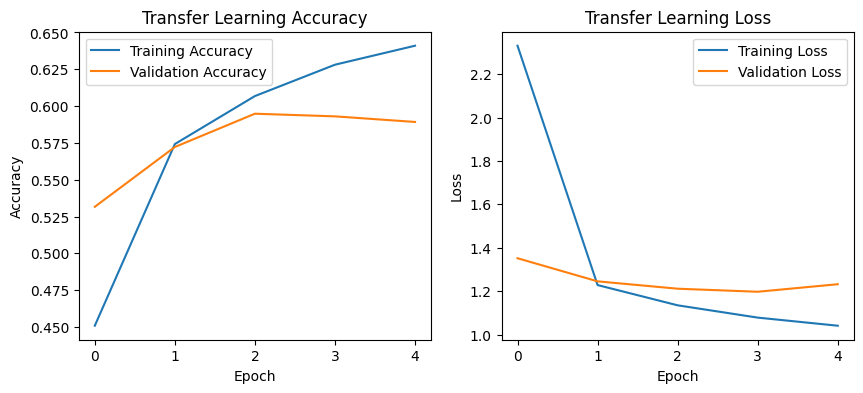

In [11]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
  )
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()